#  Project: Expectation Decider
### Mathematics & Advanced Statistics | Red & White Skill Education
---
**Objective:** Analyze probability patterns from student performance data (200 students) and derive meaningful insights using statistical techniques.

In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import binom
from matplotlib_venn import venn2

np.random.seed(42)
print(' All libraries imported successfully!')

 All libraries imported successfully!


##  Dataset Generation
Generating 200 student records with fields: `study_hours`, `attendance`, `group_discussion`, `previous_test_score`, `final_exam_pass`

In [34]:
# --- Dataset Generation ----------------------------------------------------
n = 200
np.random.seed(42)

study_hours        = np.random.randint(2, 20, n)
attendance         = np.round(np.random.uniform(40, 100, n), 1)
group_discussion   = np.random.choice(['Yes', 'No'], n, p=[0.55, 0.45])
previous_test_score = np.random.randint(30, 100, n)

# Final exam pass depends on study_hours, attendance, group_discussion, prev score
pass_prob = (
    0.3 * (study_hours > 10) +
    0.3 * (attendance > 80) +
    0.2 * (group_discussion == 'Yes') +
    0.2 * (previous_test_score > 60)
)
final_exam_pass = np.where(pass_prob >= 0.5, 'Pass', 'Fail')

df = pd.DataFrame({
    'study_hours'         : study_hours,
    'attendance'          : attendance,
    'group_discussion'    : group_discussion,
    'previous_test_score' : previous_test_score,
    'final_exam_pass'     : final_exam_pass
})

print(f'Dataset Shape : {df.shape}')
print(f'Pass Count    : {(df.final_exam_pass=="Pass").sum()}')
print(f'Fail Count    : {(df.final_exam_pass=="Fail").sum()}')
df.to_csv("expectation_decider_dataset.csv", index=False)
df.head(10)


Dataset Shape : (200, 5)
Pass Count    : 98
Fail Count    : 102


,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,8,45.6,No,45,Fail
1,16,93.8,Yes,37,Pass
2,12,94.0,Yes,33,Pass
3,9,78.0,No,33,Fail
4,8,60.3,Yes,85,Fail
5,12,61.0,No,54,Fail
6,12,83.6,No,96,Pass
7,5,93.8,Yes,96,Pass
8,9,93.2,No,56,Fail
9,4,86.8,No,61,Pass


---
## ❓ Question 1 — Understanding the Basics

###  What is Probability?

**Probability** is a numerical measure of how likely an event is to occur. It is expressed as a number between **0 and 1**, where:
- `0` = impossible event
- `1` = certain event

**Formula:**
$$P(A) = \frac{\text{Number of favorable outcomes}}{\text{Total number of outcomes}}$$

---
###  Key Probability Terminology

| Term | Definition |
|------|------------|
| **Experiment** | Any process that produces an outcome (e.g., selecting a student) |
| **Sample Space (S)** | Set of all possible outcomes |
| **Event (A)** | A subset of the sample space |
| **Complement (A')** | All outcomes NOT in A |
| **Union (A ∪ B)** | A or B or both occur |
| **Intersection (A ∩ B)** | Both A and B occur |
| **Mutually Exclusive** | A and B cannot both occur |
| **Independent Events** | Occurrence of A does not affect B |
| **Conditional Probability** | P(A\|B) = probability of A given B has occurred |

In [16]:
# --- Three Probability Event Examples from Dataset -------------------------

total = len(df)

# Event A: Student passes the final exam
P_A = (df['final_exam_pass'] == 'Pass').sum() / total

# Event B: Student studies more than 10 hours/week
P_B = (df['study_hours'] > 10).sum() / total

# Event C: Student attends more than 80% of classes
P_C = (df['attendance'] > 80).sum() / total

print('=' * 55)
print('   THREE PROBABILITY EVENT EXAMPLES FROM DATASET')
print('=' * 55)
print(f'Event A – Passes Final Exam          : P(A) = {P_A:.4f}  ({P_A*100:.1f}%)')
print(f'Event B – Studies > 10 hrs/week      : P(B) = {P_B:.4f}  ({P_B*100:.1f}%)')
print(f'Event C – Attendance > 80%           : P(C) = {P_C:.4f}  ({P_C*100:.1f}%)')
print('=' * 55)

   THREE PROBABILITY EVENT EXAMPLES FROM DATASET
Event A – Passes Final Exam          : P(A) = 0.4900  (49.0%)
Event B – Studies > 10 hrs/week      : P(B) = 0.4300  (43.0%)
Event C – Attendance > 80%           : P(C) = 0.3300  (33.0%)


---
## ❓ Question 2 — Types of Events: Empirical vs Theoretical Probability

In [17]:
# --- Empirical Probability -------------------------------------------------
# Based on actual observed data

empirical_pass = (df['final_exam_pass'] == 'Pass').sum() / total
print('EMPIRICAL PROBABILITY')
print('-----------------------------------------------------')
print('Scenario : "A randomly selected student passes the final exam"')
print(f'Observed passes    : {(df["final_exam_pass"]=="Pass").sum()}')
print(f'Total students     : {total}')
print(f'P(Pass) [Empirical]: {empirical_pass:.4f}  ({empirical_pass*100:.1f}%)')

print()

# --- Theoretical Probability -----------------------------------------------
# Assuming equal likelihood — fair coin-style assumption
# Scenario: A student either passes or fails → 2 equally likely outcomes
theoretical_pass = 1 / 2
print('THEORETICAL PROBABILITY')
print('-----------------------------------------------------')
print('Scenario : Assuming exam result is equally likely (Pass or Fail)')
print('Favorable outcomes : 1 (Pass)')
print('Total outcomes     : 2 (Pass, Fail)')
print(f'P(Pass) [Theoretical]: {theoretical_pass:.4f}  ({theoretical_pass*100:.1f}%)')

print()
print(f'Difference (Empirical - Theoretical): {empirical_pass - theoretical_pass:+.4f}')
print('→ Empirical deviates from theoretical because real-world factors (study,'
      ' attendance, etc.) influence outcomes.')

EMPIRICAL PROBABILITY
-----------------------------------------------------
Scenario : "A randomly selected student passes the final exam"
Observed passes    : 98
Total students     : 200
P(Pass) [Empirical]: 0.4900  (49.0%)

THEORETICAL PROBABILITY
-----------------------------------------------------
Scenario : Assuming exam result is equally likely (Pass or Fail)
Favorable outcomes : 1 (Pass)
Total outcomes     : 2 (Pass, Fail)
P(Pass) [Theoretical]: 0.5000  (50.0%)

Difference (Empirical - Theoretical): -0.0100
→ Empirical deviates from theoretical because real-world factors (study, attendance, etc.) influence outcomes.


---
## ❓ Question 3 — Random Variable & Probability Distribution

In [18]:
# --- Random Variable Definition --------------------------------------------
# X = Number of students passing the final exam out of 3 randomly selected
# X can take values: 0, 1, 2, 3
# This follows a Binomial Distribution: X ~ B(n=3, p=P_pass)

p = empirical_pass  
n_trials = 3

x_values = [0, 1, 2, 3]
probs = [binom.pmf(x, n_trials, p) for x in x_values]

# Probability Distribution Table
dist_df = pd.DataFrame({
    'X (No. of Students Passing)': x_values,
    'P(X)'                       : [round(p_, 4) for p_ in probs],
    'X · P(X)'                   : [round(x * p_, 4) for x, p_ in zip(x_values, probs)],
    'X² · P(X)'                  : [round(x**2 * p_, 4) for x, p_ in zip(x_values, probs)]
})

print(f'Random Variable: X = Number of students passing out of n=3')
print(f'Distribution   : X ~ Binomial(n=3, p={p:.4f})')
print()
print(dist_df.to_string(index=False))
print(f'\nSum of P(X)    : {sum(probs):.4f}  ')

# Mean and Variance
mean_X     = n_trials * p
variance_X = n_trials * p * (1 - p)
std_X      = np.sqrt(variance_X)

print(f'\nMean     E(X) = n * p         = {n_trials} * {p:.4f} = {mean_X:.4f}')
print(f'Variance Var(X) = n * p * (1-p) = {n_trials} * {p:.4f} * {1-p:.4f} = {variance_X:.4f}')
print(f'Std Dev  σ(X)  = √Var(X)        = {std_X:.4f}')

Random Variable: X = Number of students passing out of n=3
Distribution   : X ~ Binomial(n=3, p=0.4900)

 X (No. of Students Passing)   P(X)  X · P(X)  X² · P(X)
                           0 0.1327    0.0000     0.0000
                           1 0.3823    0.3823     0.3823
                           2 0.3674    0.7347     1.4694
                           3 0.1176    0.3529     1.0588

Sum of P(X)    : 1.0000  

Mean     E(X) = n * p         = 3 * 0.4900 = 1.4700
Variance Var(X) = n * p * (1-p) = 3 * 0.4900 * 0.5100 = 0.7497
Std Dev  σ(X)  = √Var(X)        = 0.8659


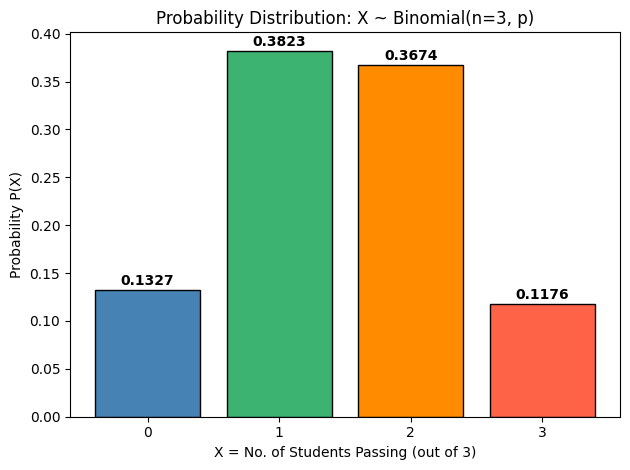

In [20]:
# Q3 - Probability Distribution Bar Chart
colors = ['steelblue', 'mediumseagreen', 'darkorange', 'tomato']
plt.bar(x_values, probs, color=colors, edgecolor='black')
for i, prob in enumerate(probs):
    plt.text(i, prob + 0.005, f'{prob:.4f}', ha='center', fontweight='bold')
plt.xlabel('X = No. of Students Passing (out of 3)')
plt.ylabel('Probability P(X)')
plt.title('Probability Distribution: X ~ Binomial(n=3, p)')
plt.xticks(x_values)
plt.tight_layout()
plt.savefig("probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


---
## ❓ Question 4 — Venn Diagram in Probability

In [21]:
# --- Venn Diagram ----------------------------------------------------------
try:
    from matplotlib_venn import venn2
    HAS_VENN = True
except ImportError:
    HAS_VENN = False

set_A = set(df[df['study_hours'] > 10].index)          
set_B = set(df[df['attendance']  > 80].index)           

only_A   = len(set_A - set_B)
only_B   = len(set_B - set_A)
both_AB  = len(set_A & set_B)
neither  = total - len(set_A | set_B)

print('VENN DIAGRAM — Study Hours & Attendance')
print('=' * 50)
print(f'Set A (study_hours > 10)          : {len(set_A)} students')
print(f'Set B (attendance  > 80%)         : {len(set_B)} students')
print(f'A ∩ B  (Both conditions)          : {both_AB} students')
print(f'A only (study > 10, attend ≤ 80%) : {only_A} students')
print(f'B only (attend > 80%, study ≤ 10) : {only_B} students')
print(f'Neither                           : {neither} students')
print()
print(f'P(A)       = {len(set_A)/total:.4f}')
print(f'P(B)       = {len(set_B)/total:.4f}')
print(f'P(A ∩ B)   = {both_AB/total:.4f}')
print(f'P(A ∪ B)   = {len(set_A|set_B)/total:.4f}')

VENN DIAGRAM — Study Hours & Attendance
Set A (study_hours > 10)          : 86 students
Set B (attendance  > 80%)         : 66 students
A ∩ B  (Both conditions)          : 26 students
A only (study > 10, attend ≤ 80%) : 60 students
B only (attend > 80%, study ≤ 10) : 40 students
Neither                           : 74 students

P(A)       = 0.4300
P(B)       = 0.3300
P(A ∩ B)   = 0.1300
P(A ∪ B)   = 0.6300


In [ ]:
# Q4 - Venn Diagram
from matplotlib_venn import venn2
v = venn2(subsets=(only_A, only_B, both_AB),
          set_labels=('Study > 10 hrs/week', 'Attendance > 80%'))
v.get_patch_by_id('10').set_color('steelblue')
v.get_patch_by_id('01').set_color('tomato')
v.get_patch_by_id('11').set_color('mediumpurple')
for patch in v.patches:
    if patch: patch.set_alpha(0.5)
plt.title('Venn Diagram: Study Hours vs Attendance')
plt.tight_layout()
plt.savefig("venn_diagram.png", dpi=300, bbox_inches="tight")
plt.show()


---
## ❓ Question 5 — Contingency Table & Probability Calculations

In [22]:
# --- Contingency Table -----------------------------------------------------
ct = pd.crosstab(df['group_discussion'], df['final_exam_pass'],
                 margins=True, margins_name='Total')
print('CONTINGENCY TABLE: group_discussion vs final_exam_pass')
print('=' * 55)
print(ct)
print()


gd_yes_pass = ct.loc['Yes', 'Pass']
gd_yes_fail = ct.loc['Yes', 'Fail']
gd_no_pass  = ct.loc['No',  'Pass']
gd_no_fail  = ct.loc['No',  'Fail']
total_pass  = ct.loc['Total', 'Pass']
total_fail  = ct.loc['Total', 'Fail']
total_yes   = ct.loc['Yes',  'Total']
total_no    = ct.loc['No',   'Total']
N           = ct.loc['Total', 'Total']


P_GD_and_Pass = gd_yes_pass / N


P_Pass = total_pass / N


P_Pass_given_GD = gd_yes_pass / total_yes

print('-' * 55)
print('PROBABILITY CALCULATIONS')
print('-' * 55)
print(f'\n1️⃣  Joint Probability  P(GD=Yes ∩ Pass)')
print(f'   = {gd_yes_pass} / {N} = {P_GD_and_Pass:.4f}  ({P_GD_and_Pass*100:.2f}%)')

print(f'\n2️⃣  Marginal Probability  P(Pass)')
print(f'   = {total_pass} / {N} = {P_Pass:.4f}  ({P_Pass*100:.2f}%)')

print(f'\n3️⃣  Conditional Probability  P(Pass | GD=Yes)')
print(f'   = P(GD=Yes ∩ Pass) / P(GD=Yes)')
print(f'   = {gd_yes_pass} / {total_yes} = {P_Pass_given_GD:.4f}  ({P_Pass_given_GD*100:.2f}%)')

CONTINGENCY TABLE: group_discussion vs final_exam_pass
final_exam_pass   Fail  Pass  Total
group_discussion                   
No                  65    35    100
Yes                 37    63    100
Total              102    98    200

-------------------------------------------------------
PROBABILITY CALCULATIONS
-------------------------------------------------------

1️⃣  Joint Probability  P(GD=Yes ∩ Pass)
   = 63 / 200 = 0.3150  (31.50%)

2️⃣  Marginal Probability  P(Pass)
   = 98 / 200 = 0.4900  (49.00%)

3️⃣  Conditional Probability  P(Pass | GD=Yes)
   = P(GD=Yes ∩ Pass) / P(GD=Yes)
   = 63 / 100 = 0.6300  (63.00%)


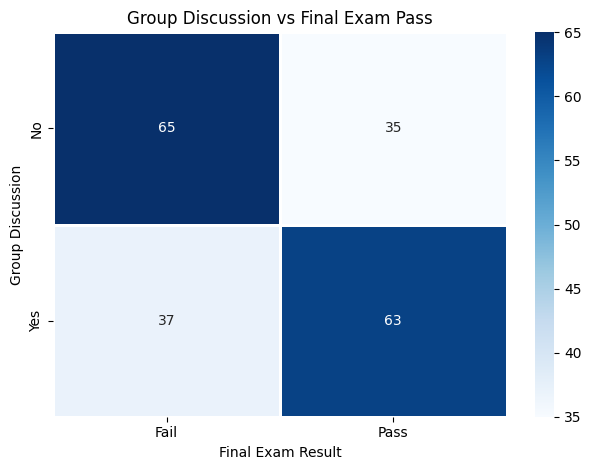

In [23]:
# Q5 - Contingency Table Heatmap
ct_raw = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
sns.heatmap(ct_raw, annot=True, fmt='d', cmap='Blues', linewidths=1)
plt.title('Group Discussion vs Final Exam Pass')
plt.xlabel('Final Exam Result')
plt.ylabel('Group Discussion')
plt.tight_layout()
plt.savefig("contingency_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


---
## ❓ Question 6 — Understanding Relationships

In [24]:
# --- Interpret Conditional Probability ------------------------------------
print('INTERPRETATION OF CONDITIONAL PROBABILITY')
print('=' * 60)
print(f'\nP(Pass | Group Discussion = Yes) = {P_Pass_given_GD:.4f} ({P_Pass_given_GD*100:.1f}%)')
print(f'P(Pass)  [Overall]              = {P_Pass:.4f} ({P_Pass*100:.1f}%)')
print()
print('Intuition:')
print('  Among ALL students, the probability of passing is'
      f' {P_Pass*100:.1f}%.')
print('  But if we KNOW a student participated in group discussions,')
print(f'  the probability of passing RISES to {P_Pass_given_GD*100:.1f}%.')
print('  This means group discussion participation is associated')
print('  with a higher chance of passing the exam.')

print()
print('-' * 60)
print('INDEPENDENCE / DEPENDENCE TEST')
print('-' * 60)
print()
print('For two events A and B to be INDEPENDENT:')
print('  P(A ∩ B) must equal P(A) * P(B)')
print()

P_GD_yes = total_yes / N
expected_joint = P_GD_yes * P_Pass

print(f'P(GD=Yes)          = {P_GD_yes:.4f}')
print(f'P(Pass)            = {P_Pass:.4f}')
print(f'P(GD=Yes) * P(Pass)= {expected_joint:.4f}  ← Expected if independent')
print(f'P(GD=Yes ∩ Pass)   = {P_GD_and_Pass:.4f}  ← Actual')
print()
if abs(P_GD_and_Pass - expected_joint) > 0.01:
    print(' CONCLUSION: P(A∩B) ≠ P(A)*P(B)')
    print('   → "Participating in group discussions" and "Passing the exam" are')
    print('     DEPENDENT EVENTS.')
    print('   → Participation in group discussion positively influences exam outcome.')
else:
    print(' CONCLUSION: P(A∩B) ≈ P(A)*P(B)')
    print('   → The events are approximately INDEPENDENT.')

print()
print('Mutually Exclusive?')
print('  For mutually exclusive: P(A ∩ B) = 0')
print(f'  P(GD=Yes ∩ Pass) = {P_GD_and_Pass:.4f} ≠ 0')
print('  → They are NOT mutually exclusive (students CAN both participate AND pass).')

INTERPRETATION OF CONDITIONAL PROBABILITY

P(Pass | Group Discussion = Yes) = 0.6300 (63.0%)
P(Pass)  [Overall]              = 0.4900 (49.0%)

Intuition:
  Among ALL students, the probability of passing is 49.0%.
  But if we KNOW a student participated in group discussions,
  the probability of passing RISES to 63.0%.
  This means group discussion participation is associated
  with a higher chance of passing the exam.

------------------------------------------------------------
INDEPENDENCE / DEPENDENCE TEST
------------------------------------------------------------

For two events A and B to be INDEPENDENT:
  P(A ∩ B) must equal P(A) * P(B)

P(GD=Yes)          = 0.5000
P(Pass)            = 0.4900
P(GD=Yes) * P(Pass)= 0.2450  ← Expected if independent
P(GD=Yes ∩ Pass)   = 0.3150  ← Actual

 CONCLUSION: P(A∩B) ≠ P(A)*P(B)
   → "Participating in group discussions" and "Passing the exam" are
     DEPENDENT EVENTS.
   → Participation in group discussion positively influences exam outcom

---
## ❓ Question 7 — Bayes' Theorem Application

In [25]:
# --- Bayes' Theorem --------------------------------------------------------
# Given historical data:
#   P(High Attendance | Pass) = 0.70
#   P(High Attendance | Fail) = 0.40
#   P(High Attendance)        = 0.60
#
# Find: P(Pass | High Attendance)

P_HA_given_Pass = 0.70   # P(High Attendance | Pass)
P_HA_given_Fail = 0.40   # P(High Attendance | Fail)
P_HA            = 0.60   # P(High Attendance)

# P(Pass) from our dataset (empirical prior)
P_pass_prior = empirical_pass
P_fail_prior = 1 - P_pass_prior

# Bayes' Theorem:
# P(Pass | HA) = P(HA | Pass) * P(Pass) / P(HA)

# Verify P(HA) using Total Probability Theorem
P_HA_calculated = P_HA_given_Pass * P_pass_prior + P_HA_given_Fail * P_fail_prior

# Use given P(HA) = 0.60
P_Pass_given_HA = (P_HA_given_Pass * P_pass_prior) / P_HA

print('BAYES\' THEOREM APPLICATION')
print('=' * 60)
print()
print('Given:')
print(f'  P(High Attendance | Pass) = {P_HA_given_Pass}')
print(f'  P(High Attendance | Fail) = {P_HA_given_Fail}')
print(f'  P(High Attendance)        = {P_HA}')
print(f'  P(Pass) [prior, empirical]= {P_pass_prior:.4f}')
print(f'  P(Fail) [prior]           = {P_fail_prior:.4f}')
print()
print('Formula:')
print('  P(Pass | HA) = P(HA | Pass) * P(Pass)')
print('                 -------------------------')
print('                        P(HA)')
print()
print('Substituting Values:')
print(f'  P(Pass | HA) = ({P_HA_given_Pass} * {P_pass_prior:.4f}) / {P_HA}')
print(f'               = {P_HA_given_Pass * P_pass_prior:.4f} / {P_HA}')
print(f'               = {P_Pass_given_HA:.4f}')
print()
print('-' * 60)
print(f' P(Pass | High Attendance) = {P_Pass_given_HA:.4f} ({P_Pass_given_HA*100:.2f}%)')
print('-' * 60)
print()
print('Interpretation:')
print('  If we know a student had HIGH ATTENDANCE (>80%),')
print(f'  the probability they PASSED the exam is {P_Pass_given_HA*100:.1f}%.')
print(f'  This is higher than the overall pass rate of {P_pass_prior*100:.1f}%,')
print('  confirming that high attendance is a strong positive indicator.')

BAYES' THEOREM APPLICATION

Given:
  P(High Attendance | Pass) = 0.7
  P(High Attendance | Fail) = 0.4
  P(High Attendance)        = 0.6
  P(Pass) [prior, empirical]= 0.4900
  P(Fail) [prior]           = 0.5100

Formula:
  P(Pass | HA) = P(HA | Pass) * P(Pass)
                 -------------------------
                        P(HA)

Substituting Values:
  P(Pass | HA) = (0.7 * 0.4900) / 0.6
               = 0.3430 / 0.6
               = 0.5717

------------------------------------------------------------
 P(Pass | High Attendance) = 0.5717 (57.17%)
------------------------------------------------------------

Interpretation:
  If we know a student had HIGH ATTENDANCE (>80%),
  the probability they PASSED the exam is 57.2%.
  This is higher than the overall pass rate of 49.0%,
  confirming that high attendance is a strong positive indicator.


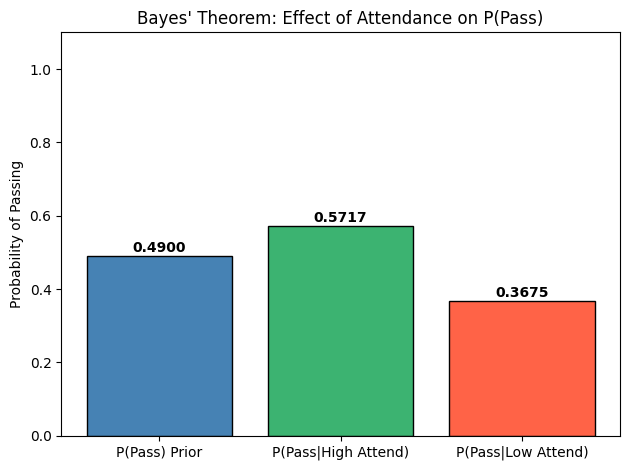

In [26]:
# Q7 - Bayes Theorem Bar Chart
P_low_HA_given_Pass = 1 - P_HA_given_Pass
P_low_HA = 1 - P_HA
P_Pass_given_LowHA = (P_low_HA_given_Pass * P_pass_prior) / P_low_HA

labels = ['P(Pass) Prior', 'P(Pass|High Attend)', 'P(Pass|Low Attend)']
values = [P_pass_prior, P_Pass_given_HA, P_Pass_given_LowHA]
colors = ['steelblue', 'mediumseagreen', 'tomato']

plt.bar(labels, values, color=colors, edgecolor='black')
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.ylabel('Probability of Passing')
plt.title("Bayes' Theorem: Effect of Attendance on P(Pass)")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("bayes_theorem.png", dpi=300, bbox_inches="tight")
plt.show()


---
##  Final Summary — Key Insights

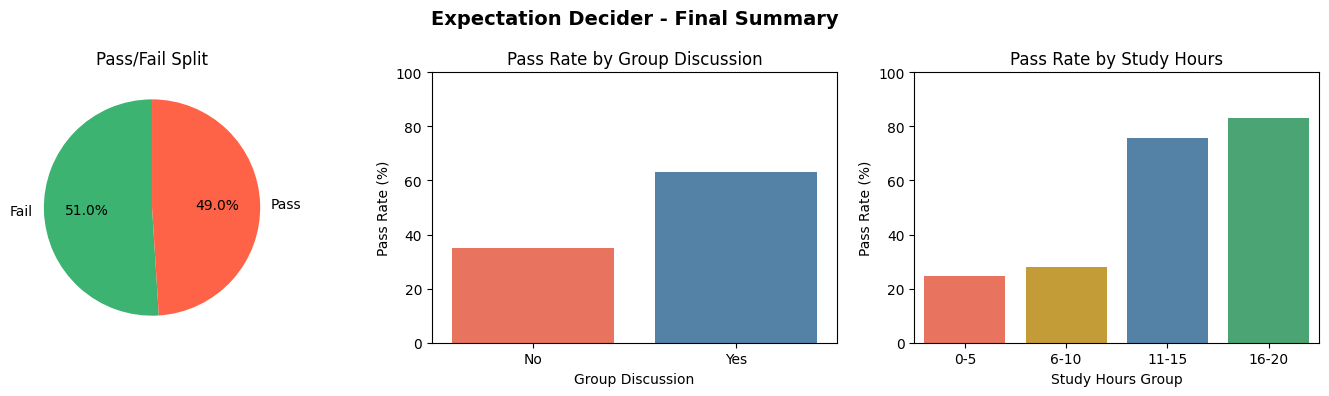

FINAL SUMMARY - KEY FINDINGS
1. Overall Pass Rate                       : 49.0%
2. P(Pass | Group Discussion = Yes)        : 63.0%
3. P(Pass | High Attendance) [Bayes]       : 57.2%
4. Mean E(X) out of 3 students             : 1.4700
5. Variance Var(X)                         : 0.7497

Factors most affecting probability of passing:
  - High attendance (>80%)
  - Group discussion participation
  - More study hours
  - High previous test score


In [27]:
# Final Summary - 3 Charts using Seaborn & direct groupby

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Expectation Decider - Final Summary', fontsize=14, fontweight='bold')

# Chart 1: Pie chart - Pass/Fail split
counts = df['final_exam_pass'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['mediumseagreen', 'tomato'], startangle=90)
axes[0].set_title('Pass/Fail Split')

# Chart 2: Seaborn barplot - Pass Rate by Group Discussion
df['passed'] = (df['final_exam_pass'] == 'Pass').astype(int) * 100
sns.barplot(data=df, x='group_discussion', y='passed',
            hue='group_discussion', palette=['tomato', 'steelblue'],
            ax=axes[1], errorbar=None, legend=False)
axes[1].set_title('Pass Rate by Group Discussion')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].set_xlabel('Group Discussion')
axes[1].set_ylim(0, 100)

# Chart 3: Seaborn barplot - Pass Rate by Study Hours group
df['study_group'] = pd.cut(df['study_hours'], bins=[0, 5, 10, 15, 20],
                            labels=['0-5', '6-10', '11-15', '16-20'])
sns.barplot(data=df, x='study_group', y='passed',
            hue='study_group', palette=['tomato', 'goldenrod', 'steelblue', 'mediumseagreen'],
            ax=axes[2], errorbar=None, legend=False,
            order=['0-5', '6-10', '11-15', '16-20'])
axes[2].set_title('Pass Rate by Study Hours')
axes[2].set_xlabel('Study Hours Group')
axes[2].set_ylabel('Pass Rate (%)')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig("final_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# Print key findings
results = {
    'Overall Pass Rate'                  : f'{empirical_pass*100:.1f}%',
    'P(Pass | Group Discussion = Yes)'   : f'{P_Pass_given_GD*100:.1f}%',
    'P(Pass | High Attendance) [Bayes]'  : f'{P_Pass_given_HA*100:.1f}%',
    'Mean E(X) out of 3 students'        : f'{mean_X:.4f}',
    'Variance Var(X)'                    : f'{variance_X:.4f}',
}

print('=' * 55)
print('FINAL SUMMARY - KEY FINDINGS')
print('=' * 55)
for i, (k, v) in enumerate(results.items(), 1):
    print(f'{i}. {k:40s}: {v}')
print()
print('Factors most affecting probability of passing:')
factors = ['High attendance (>80%)', 'Group discussion participation',
           'More study hours', 'High previous test score']
for f in factors:
    print(f'  - {f}')
print('=' * 55)
